In [1]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 7.42]

In [3]:
def acc(x1: float, v1: float, x2: float, v2: float, L1: float = 1.0, L2: float = 1.0, m1: float = 1.0, m2: float = 1.0) -> tuple[float, float, float, float]:
    """
    Funzione che accetta 4 parametri, i primi due legati alla posizione e gli ultimi due legati alla velocità, 
    e restituisce un vettore di lunghezza 4 che contiene le derivate prime dei parametri in entrata:
    detti x1, v1, x2, v2 i parametri in entrata restituisce v1, a1, v2, a2.
    """
    g = 9.81
    dx = x1 - x2
    
    num1 = -g * (2*m1 + m2) * np.sin(x1) - m2 * g * np.sin(x1 - 2*x2) - 2 * np.sin(dx) * m2 * (v2**2 * L2 + v1**2 * L1 * np.cos(dx))
    den1 = L1 * (2*m1 + m2 - m2 * np.cos(2*dx))
    a1 = num1/den1
    
    num2 = 2 * np.sin(dx) * (v1**2 * L1 * (m1 + m2) + g * (m1 + m2) * np.cos(x1) + v2**2 * L2 * m2 * np.cos(dx))
    den2 = L2 * (2*m1 + m2 - m2 * np.cos(2*(dx)))
    a2 = num2/den2
    
    return v1, a1, v2, a2

In [4]:
# la funzione non aggiorna correttamente i coefficienti, rivedere l'implementazione utilizzando liste per ognuna delle quattro variabili
def rk4(theta1: float, theta2: float, omega1: float, omega2: float, h: float, times: list[float], f: callable) -> tuple[list[float], list[float], list[float], list[float]]:
    h_mezzi, h_sesti = h/2, h/6
    p1, v1 = np.zeros(len(times)), np.zeros(len(times))
    p2, v2 = np.zeros(len(times)), np.zeros(len(times))

    p1[0], v1[0], p2[0], v2[0] = theta1, omega1, theta2, omega2

    for i in range(1, len(times)):
        k1x1, k1v1, k1x2, k1v2 = f(p1[i-1], v1[i-1], p2[i-1], v2[i-1])
        k2x1, k2v1, k2x2, k2v2 = f(p1[i-1] + h_mezzi * k1x1, v1[i-1] + h_mezzi * k1v1, p2[i-1] + h_mezzi * k1x2, v2[i-1] + h_mezzi * k1v2)
        k3x1, k3v1, k3x2, k3v2 = f(p1[i-1] + h_mezzi * k2x1, v1[i-1] + h_mezzi * k2v1, p2[i-1] + h_mezzi * k2x2, v2[i-1] + h_mezzi * k2v2)
        k4x1, k4v1, k4x2, k4v2 = f(p1[i-1] + h * k3x1, v1[i-1] + h * k3v1, p2[i-1] + h * k3x2, v2[i-1] + h * k3v2)

        p1[i] = p1[i-1] + h_sesti * (k1x1 + 2*k2x1 + 2*k3x1 + k4x1)
        v1[i] = v1[i-1] + h_sesti * (k1v1 + 2*k2v1 + 2*k3v1 + k4v1)
        p2[i] = p2[i-1] + h_sesti * (k1x2 + 2*k2x2 + 2*k3x2 + k4x2)
        v2[i] = v2[i-1] + h_sesti * (k1v2 + 2*k2v2 + 2*k3v2 + k4v2)
    return p1, v1, p2, v2

h = 0.001
times = np.arange(0, 20, h)

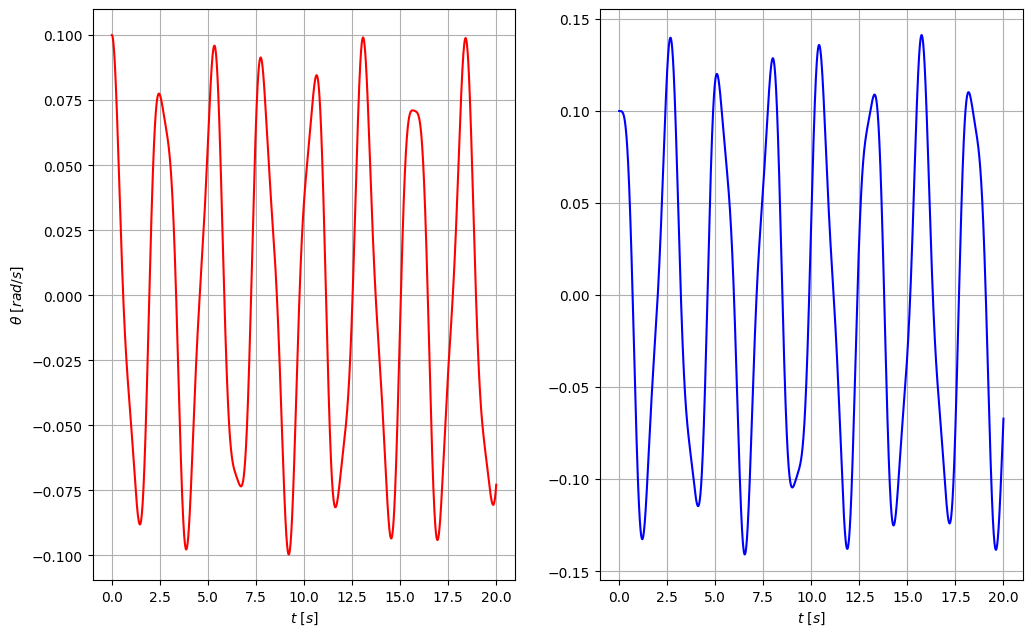

In [5]:
p1, v1, p2, v2 = rk4(theta1=0.1, theta2=0.1, omega1=0.0, omega2= 0.0, h=h, times=times, f=acc)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(times, p1, color="red")
ax1.set_xlabel(r"$t\ [s]$")
ax1.set_ylabel(r"$\theta\ [rad/s]$")
ax1.grid(True)

ax2.plot(times, p2, color="blue")
ax2.set_xlabel(r"$t\ [s]$")
ax2.grid(True)

plt.show()

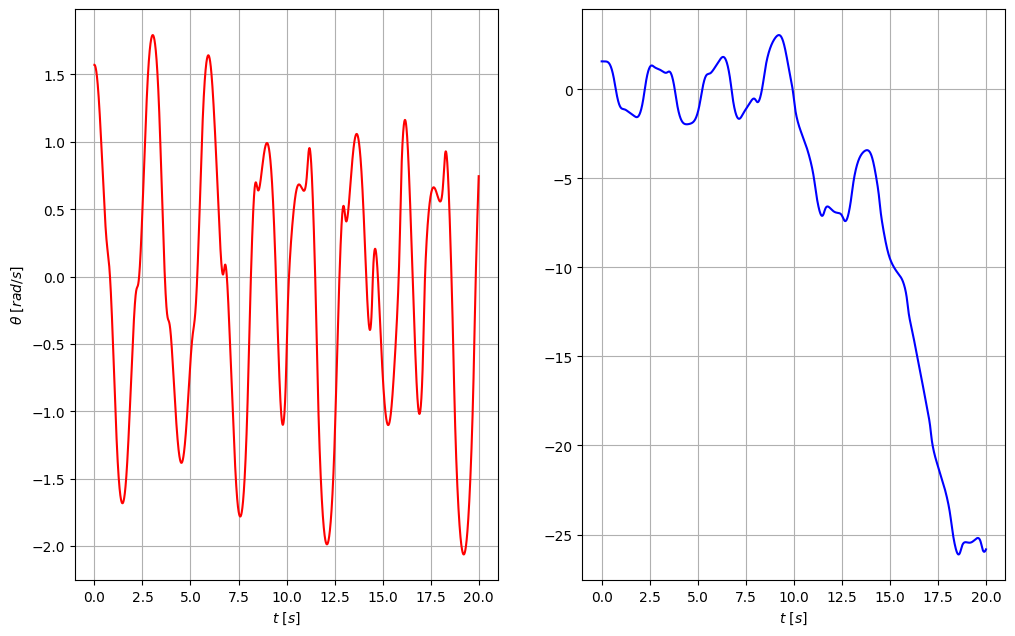

In [6]:
# GRANDI OSCILLAZIONI
p1, v1, p2, v2 = rk4(theta1=np.pi/2, theta2=np.pi/2, omega1=0.0, omega2= 0.0, h=h, times=times, f=acc)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(times, p1, color="red")
ax1.set_xlabel(r"$t\ [s]$")
ax1.set_ylabel(r"$\theta\ [rad/s]$")
ax1.grid(True)

ax2.plot(times, p2, color="blue")
ax2.set_xlabel(r"$t\ [s]$")
ax2.grid(True)
plt.show()

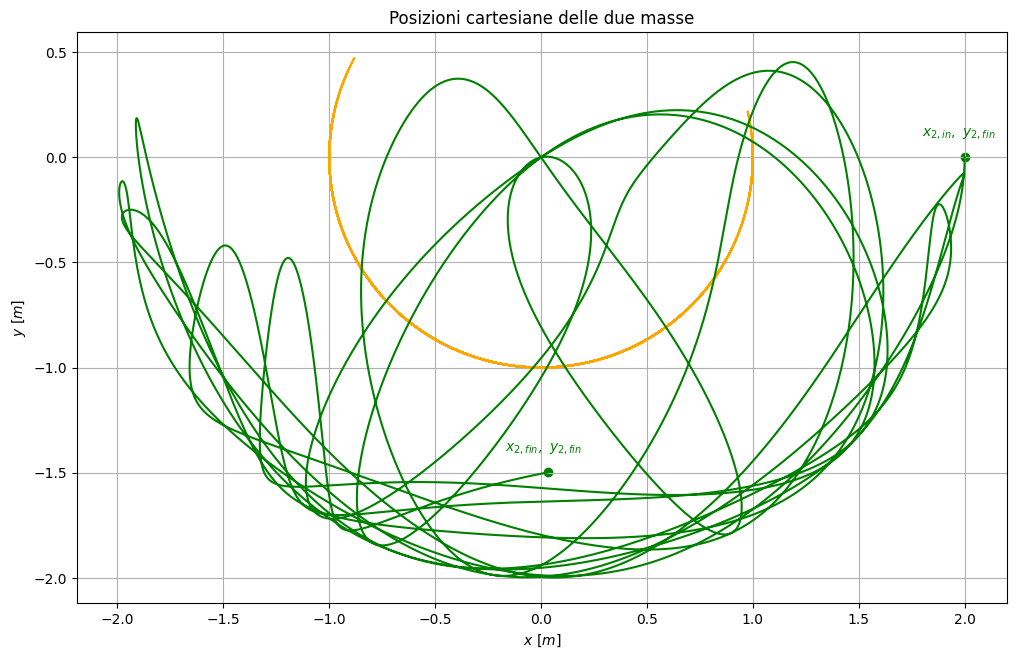

In [7]:
x1, y1 = np.sin(p1), -np.cos(p1)
x2, y2 = x1 + np.sin(p2), y1 - np.cos(p2)

plt.plot(x1, y1, color="orange")
plt.plot(x2, y2, color="green")
plt.grid()
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$y\ [m]$")
plt.title("Posizioni cartesiane delle due masse")
plt.scatter(x2[0], y2[0], color="green")
plt.text(x2[0]-0.2, y2[0]+0.1, s=r"$x_{2,in},\ y_{2,fin}$", fontweight="bold", color="green")
plt.scatter(x2[-1], y2[-1], color="green")
plt.text(x2[-1]-0.2, y2[-1]+0.1, s=r"$x_{2,fin},\ y_{2,fin}$", fontweight="bold", color="green")

plt.show()

In [16]:
def energy(x1: float, v1: float, x2: float, v2: float, m1: float = 1, m2: float = 1, L1: float = 1, L2: float = 1) -> float:
    g = 9.81
    kin = 0.5 * m1 * L1**2 * v1**2 + 0.5 * m2 * (L1**2 * v1**2 + L2**2 * v2**2 + 2 * L1 * L2 * v1 * v2 * np.cos(x1-x2))
    pot = -(m1 + m2) * g * L1 * np.cos(x1) - m2 * g * L2 * np.cos(x2)

    return kin + pot

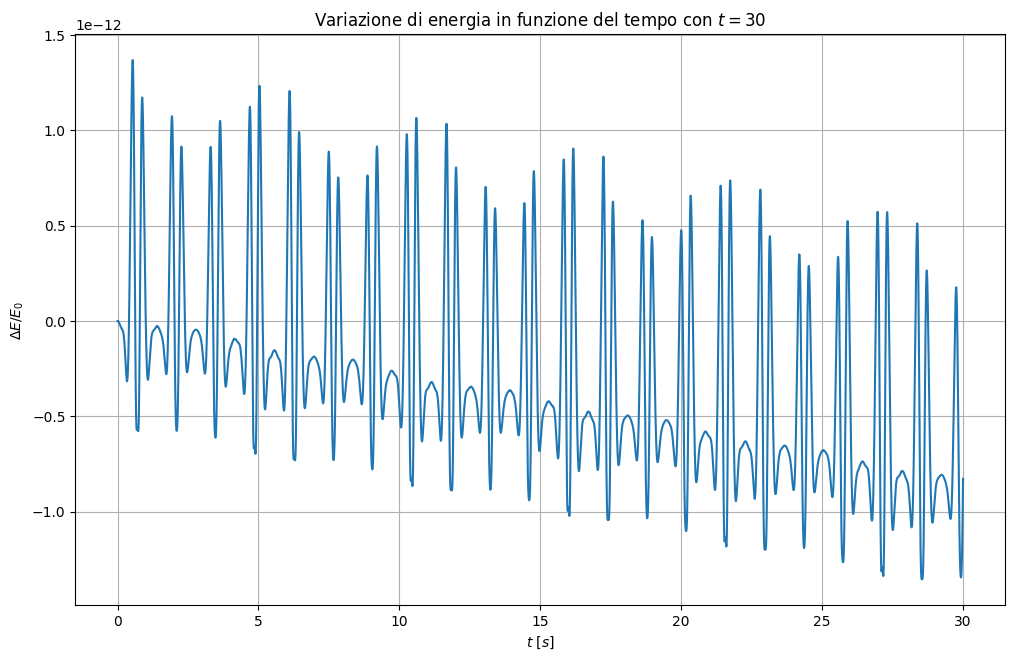

In [44]:
# GRANDI OSCILLAZIONI
times = np.arange(0, 30, h)
p1, v1, p2, v2 = rk4(theta1=np.pi/3, theta2=np.pi/3, omega1=0.0, omega2= 0.0, h=h, times=times, f=acc)
en = energy(x1=p1, v1=v1, x2=p2, v2=v2)
en0 = energy(x1=np.pi/3, v1=0.0, x2=np.pi/3, v2=0.0)

plt.plot(times, (en-en0)/abs(en0))
plt.xlabel(r"$t\ [s]$")
plt.ylabel(r"$\Delta E/E_0$")
plt.title(rf"Variazione di energia in funzione del tempo con $t=30$")
plt.grid()
plt.show()

In [47]:
print(np.max(en-en0)/abs(en0))

1.3685733936989899e-12


In [64]:
p1a, v1a, p2a, v2a = rk4(theta1=np.pi/2, theta2=np.pi/2, omega1=0.0, omega2=0.0, h=h, times=times, f=acc)
p1b, v1b, p2b, v2b = rk4(theta1=np.pi/2+10e-6, theta2=np.pi/2+10e-6, omega1=0.0, omega2=0.0, h=h, times=times, f=acc)

t0 = np.argmax(np.abs(p1a-p1b)>10e-2)

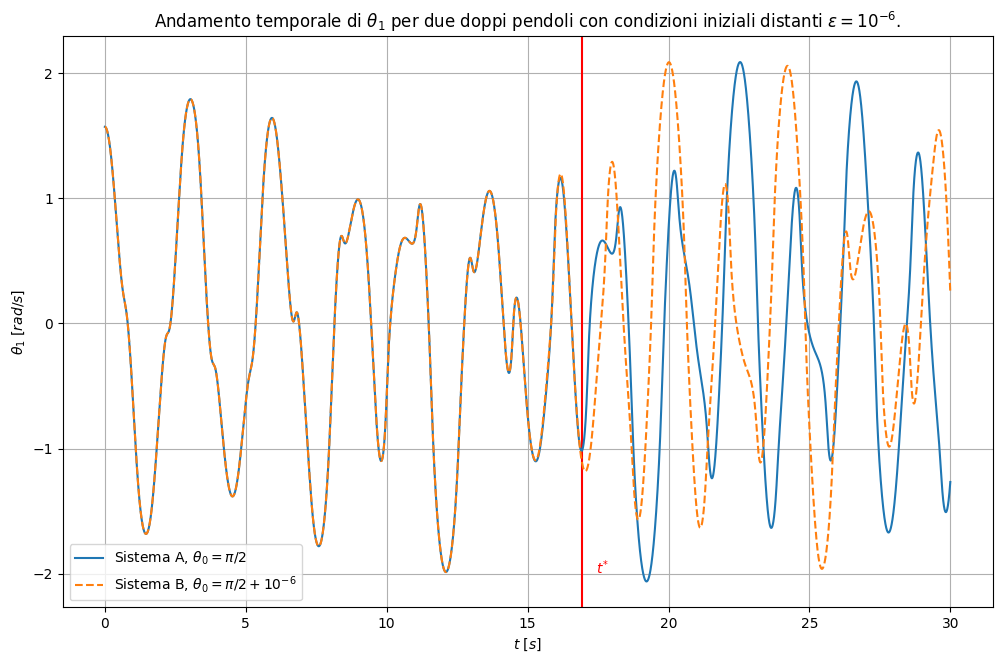

In [76]:
plt.axvline(times[t0], color="red")
plt.text(times[t0]+0.5, -2, s=r"$t^{*}$", color="red")
plt.plot(times, p1a, label=r"Sistema A, $\theta_0=\pi/2$")
plt.plot(times, p1b, "--", label=r"Sistema B, $\theta_0=\pi/2 + 10^{-6}$")
plt.xlabel(r"$t\ [s]$")
plt.ylabel(r"$\theta_1\ [rad/s]$")
plt.title(r"Andamento temporale di $\theta_1$ per due doppi pendoli con condizioni iniziali distanti $\varepsilon=10^{-6}$.")
plt.grid()
plt.legend()
plt.show()

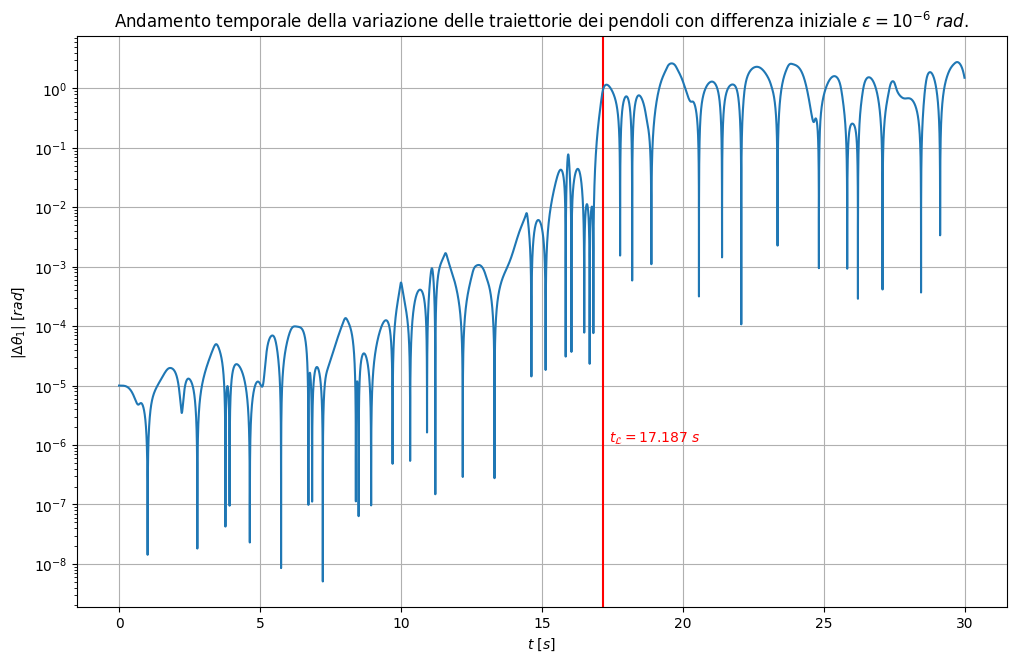

In [105]:
dtheta = np.abs(p1a-p1b)
t_ljapunov = np.argmax(dtheta>1)
plt.axvline(times[t_ljapunov], color="red")
plt.text(times[t_ljapunov]+0.2, 10e-8+10e-7, s=rf"$t_{{\mathcal{{L}}}}={times[t_ljapunov]}\ s$", color="red")
plt.plot(times, dtheta)
plt.xlabel(r"$t\ [s]$")
plt.yscale("log")
plt.ylabel(r"$|\Delta\theta_1|\ [rad]$")
plt.title(r"Andamento temporale della variazione delle traiettorie dei pendoli con differenza iniziale $\varepsilon=10^{-6}\ rad$.")
plt.grid()
plt.show()

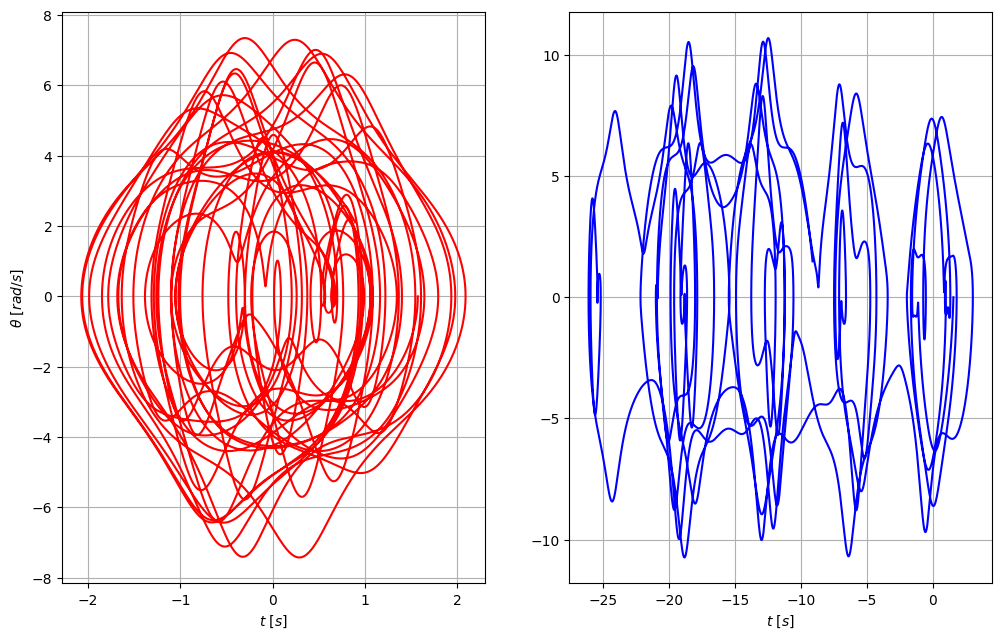

In [106]:
# GRANDI OSCILLAZIONI
times = np.arange(0, 50, h)
p1, v1, p2, v2 = rk4(theta1=np.pi/2, theta2=np.pi/2, omega1=0.0, omega2= 0.0, h=h, times=times, f=acc)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(p1, v1, color="red")
ax1.set_xlabel(r"$t\ [s]$")
ax1.set_ylabel(r"$\theta\ [rad/s]$")
ax1.grid(True)

ax2.plot(p2, v2, color="blue")
ax2.set_xlabel(r"$t\ [s]$")
ax2.grid(True)
plt.show()